In [2]:
import pandas as pd
df = pd .read_csv("Palo Alto Networks (1).csv")
df.head()
df.info()

print(df.shape)



<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

In [3]:
#missing values
df.isnull().sum()
df = df.drop_duplicates()
print('after:',len(df))
#removing
df = df.dropna()

print(df.shape)
df.describe()

after: 1470
(1470, 31)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


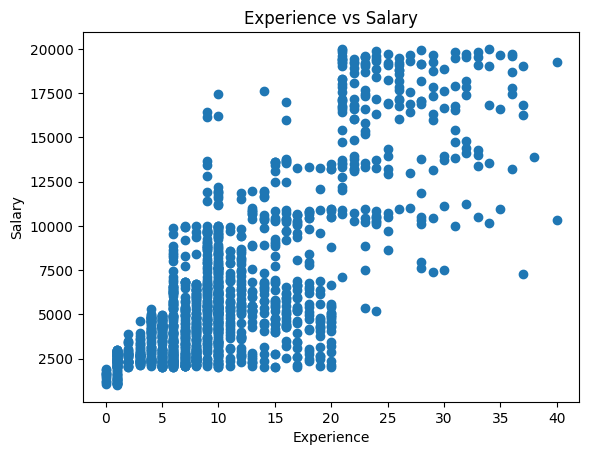

In [4]:
#count
df['Department'].value_counts()
df['Attrition'].value_counts()
df.groupby("Department")['Attrition'].mean()
df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
#analysis chart
import matplotlib.pyplot as plt

plt.scatter(df['TotalWorkingYears'], df['MonthlyIncome'])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()
df.groupby("WorkLifeBalance")['Attrition'].mean()
#feature engineering
df['PromotionGapRatio'] = (df['YearsSinceLastPromotion']/(df['YearsAtCompany']+1))

In [6]:
#feature engineering
df['PromotionGapRatio'] = (df['YearsSinceLastPromotion']/(df['YearsAtCompany']+1))
df['RoleStagnationIndex'] = (df['YearsInCurrentRole'] /(df['YearsAtCompany']+1))
df['TrainingIntensityScore'] = (df['TrainingTimesLastYear']/(df['YearsAtCompany']+1))
df['ManagerStabilityIndicator'] = (df['YearsWithCurrManager']/(df['YearsAtCompany']+1))


df[['PromotionGapRatio','RoleStagnationIndex','TrainingIntensityScore','ManagerStabilityIndicator']].head()
df[['PromotionGapRatio','RoleStagnationIndex','TrainingIntensityScore','ManagerStabilityIndicator']].describe()



,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.236458,0.480701,0.623948,0.465510
std,0.269358,0.274128,0.714059,0.276763
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.333333,0.222222,0.285714
50%,0.142857,0.500000,0.400000,0.500000
75%,0.428571,0.666667,0.750000,0.666667
max,0.916667,0.882353,6.000000,0.894737


In [7]:
features = [
      'PromotionGapRatio',
      'RoleStagnationIndex',
       'TrainingIntensityScore',
       'ManagerStabilityIndicator',
      'YearsAtCompany',
   'JobLevel']


X = df[features]
X.head()



,PromotionGapRatio,RoleStagnationIndex,TrainingIntensityScore,ManagerStabilityIndicator,YearsAtCompany,JobLevel
0,0.000000,0.571429,0.000000,0.714286,6,2
1,0.090909,0.636364,0.272727,0.636364,10,2
2,0.000000,0.000000,3.000000,0.000000,0,1
3,0.333333,0.777778,0.333333,0.000000,8,1
4,0.666667,0.666667,1.000000,0.666667,2,1


In [10]:
#scaling
from sklearn .preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])


#k means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df['Cluster'].value_counts()

#analysis
df.groupby('Cluster')[[
      'PromotionGapRatio',
          'RoleStagnationIndex',
              'TrainingIntensityScore',
                  'ManagerStabilityIndicator',
                      'YearsAtCompany',
                          'JobLevel'
                          ]].mean()



df['Cluster'].value_counts()











[[-0.87815341  0.33107966 -0.87410186  0.8991851  -0.16461311 -0.05778755]
 [-0.54053624  0.56803864 -0.49203239  0.61754092  0.48850773 -0.05778755]
 [-0.87815341 -1.75415936  3.3286623  -1.6825532  -1.14429437 -0.96148639]
 [ 0.35977622  1.08408264 -0.40712807 -1.6825532   0.16194731 -0.96148639]
 [ 1.59770584  0.67861949  0.52681953  0.72706921 -0.81773395 -0.96148639]]


Cluster
0    752
1    328
3    220
2    170
Name: count, dtype: int64

In [11]:
#promotional gap ratio
def promotion_gap_score(x):
      if x < 0.2:
              return "Low"
      elif x < 0.5:
              return "Medium"
      else:
              return "High"

df['PromotionGapScore'] = df['PromotionGapRatio'].apply(promotion_gap_score)


df['TrainingNeedIndicator'] = df['TrainingIntensityScore'].apply(
      lambda x: "Yes" if x < 0.3 else "No"
      )


df['ManagerStabilityImpact'] = df['ManagerStabilityIndicator'].apply(
      lambda x: "High" if x > 0.7 else "Moderate"
      )


df['RetentionOpportunityIndex'] = (
      df['PromotionGapRatio'] * 0.5
          +
              df['RoleStagnationIndex'] * 0.3
                  -
                      df['TrainingIntensityScore'] * 0.2
                      )

print(df)



      Age  Attrition     BusinessTravel  DailyRate              Department  \
0      41          1      Travel_Rarely       1102                   Sales   
1      49          0  Travel_Frequently        279  Research & Development   
2      37          1      Travel_Rarely       1373  Research & Development   
3      33          0  Travel_Frequently       1392  Research & Development   
4      27          0      Travel_Rarely        591  Research & Development   
...   ...        ...                ...        ...                     ...   
1465   36          0  Travel_Frequently        884  Research & Development   
1466   39          0      Travel_Rarely        613  Research & Development   
1467   27          0      Travel_Rarely        155  Research & Development   
1468   49          0  Travel_Frequently       1023                   Sales   
1469   34          0      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EnvironmentSa

In [14]:
#cluster finding 
df['PromotionGapScore']
df['TrainingNeedIndicator']
df['ManagerStabilityImpact']
df['RetentionOpportunityIndex']

#high risk employees
high_risk = df[df['PromotionGapRatio']== 'High']

print(high_risk.head())
print("Total High Risk Employees :",len(high_risk))

#retention oppurtunity employees 
retention_opportunity = df[
    (df['Attrition'] == 0) &
    (df['PromotionGapScore'] == 'High')
]

print(retention_opportunity.head())


Empty DataFrame
Columns: [Age, Attrition, BusinessTravel, DailyRate, Department, DistanceFromHome, Education, EducationField, EnvironmentSatisfaction, Gender, HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction, MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked, OverTime, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, PromotionGapRatio, RoleStagnationIndex, TrainingIntensityScore, ManagerStabilityIndicator, Cluster, PromotionGapScore, TrainingNeedIndicator, ManagerStabilityImpact, RetentionOpportunityIndex]
Index: []

[0 rows x 40 columns]
Total High Risk Employees : 0
    Age  Attrition BusinessTravel  DailyRate              Department  \
4    27          0  Travel_Rarely        591  Research & Development   
9    36          0  Travel_Rarely       1299  Research & Development   
12   31 

In [18]:
#cluster summary
cluster_summary = df.groupby('Cluster')[[
    'PromotionGapRatio',
    'RoleStagnationIndex',
    'TrainingIntensityScore',
    'RetentionOpportunityIndex'
]].mean()

print(cluster_summary)


#Label Clusters 
cluster_labels = {
    0: 'Fast Track Performers',
    1: 'Stable Contributors',
    2: 'Early Career Explorers',
    3: 'Promotion-Stagnant Employees'
}

df['CareerCluster'] = df['Cluster'].map(cluster_labels)



#Department analysis
df.groupby('Department')['RetentionOpportunityIndex'].mean()

#job role analysis
df.groupby('JobRole')['RetentionOpportunityIndex'].mean()

         PromotionGapRatio  RoleStagnationIndex  TrainingIntensityScore  \
Cluster                                                                   
0                 0.099306             0.541713                0.440248   
1                 0.647702             0.646473                0.504719   
2                 0.306270             0.458237                0.165484   
3                 0.038193             0.042359                1.783896   

         RetentionOpportunityIndex  
Cluster                             
0                         0.124117  
1                         0.416849  
2                         0.257509  
3                        -0.324975  


JobRole
Healthcare Representative    0.174809
Human Resources              0.133270
Laboratory Technician        0.071496
Manager                      0.211502
Manufacturing Director       0.173040
Research Director            0.186658
Research Scientist           0.109704
Sales Executive              0.184388
Sales Representative         0.003091
Name: RetentionOpportunityIndex, dtype: float64

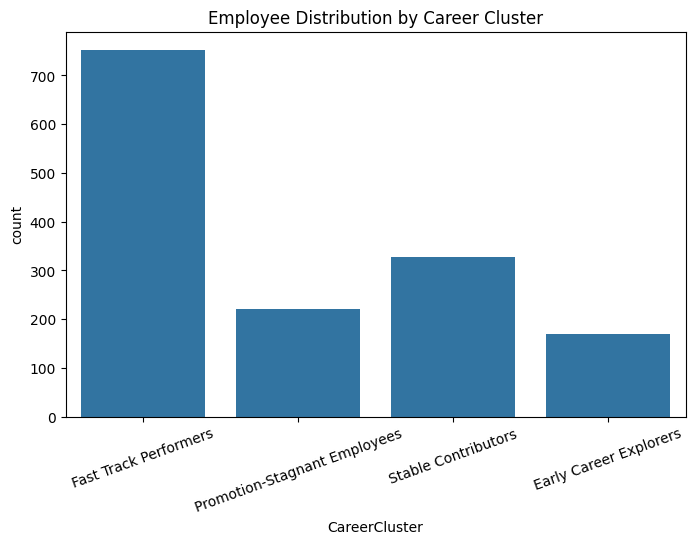

In [19]:
#charts 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x='CareerCluster', data=df)

plt.title("Employee Distribution by Career Cluster")
plt.xticks(rotation=20)

plt.show()

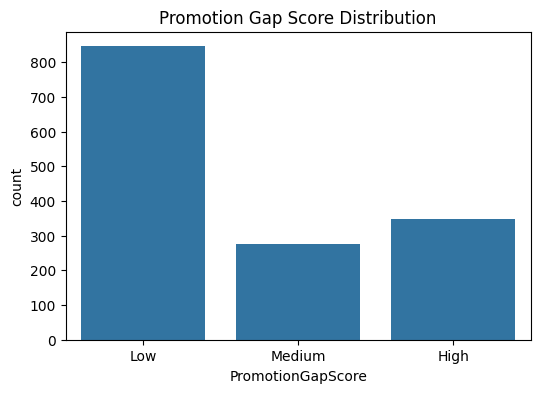

In [ ]:
#promotional gap ratio
plt.figure(figsize=(6,3))

sns.countplot(x='PromotionGapScore', data=df)

plt.title("Promotion Gap Score Distribution")

plt.show()

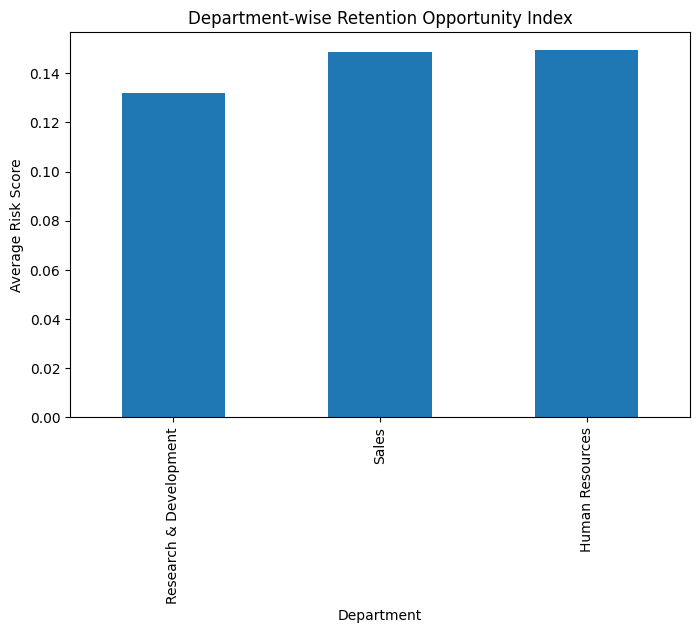

In [21]:
#retention oppurtunity
dept_risk = df.groupby('Department')[
    'RetentionOpportunityIndex'
].mean().sort_values()

plt.figure(figsize=(8,5))

dept_risk.plot(kind='bar')

plt.title("Department-wise Retention Opportunity Index")
plt.ylabel("Average Risk Score")

plt.show()

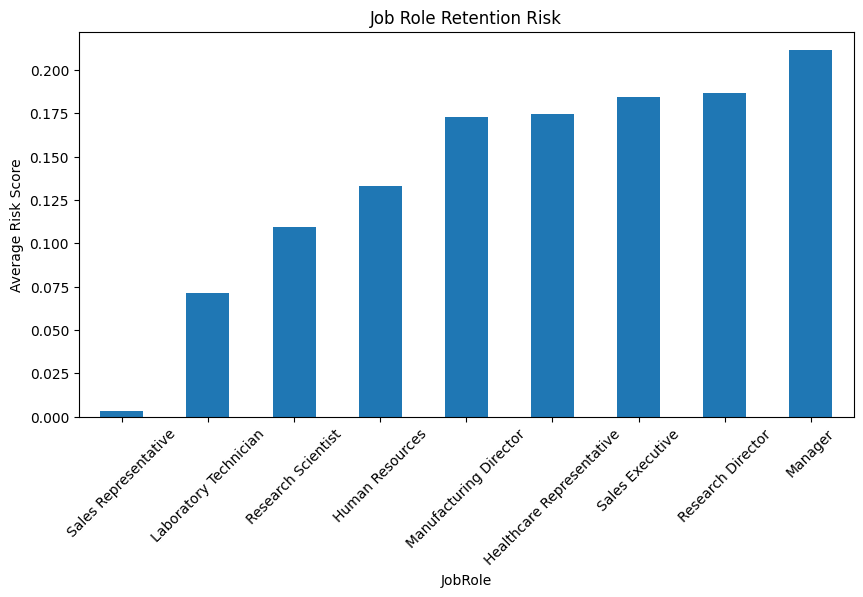

In [22]:
#job role analysis
role_risk = df.groupby('JobRole')[
    'RetentionOpportunityIndex'
].mean().sort_values()

plt.figure(figsize=(10,5))

role_risk.plot(kind='bar')

plt.title("Job Role Retention Risk")
plt.ylabel("Average Risk Score")

plt.xticks(rotation=45)

plt.show()

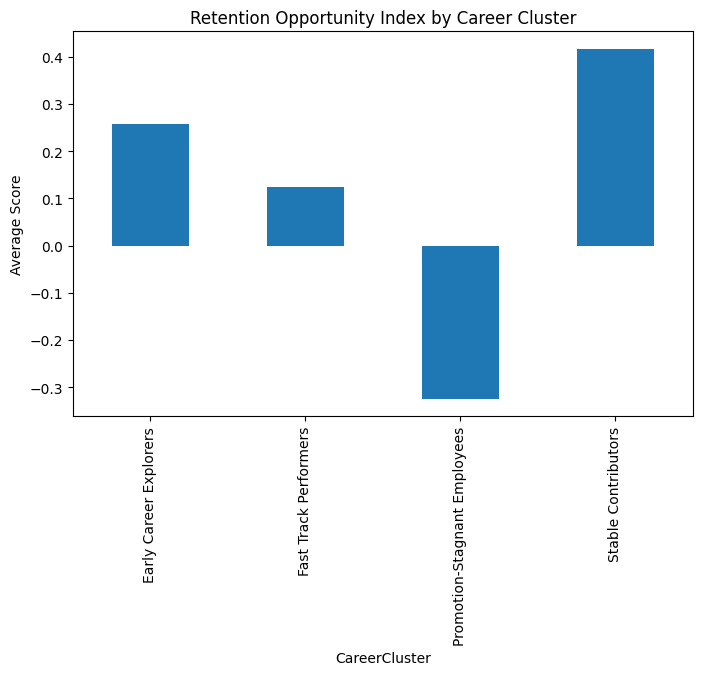

In [ ]:
#cluster vs retention oppurtunity 
cluster_risk = df.groupby('CareerCluster')[
    'RetentionOpportunityIndex'
].mean()

plt.figure(figsize=(8,5))

cluster_risk.plot(kind='bar')

plt.title("Retention Opportunity Index by Career Cluster")
plt.ylabel("Average Score")

plt.show()





In [ ]:
df.to_csv("final_employee_analysis.csv", index=False)

: 